In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from datasets import load_dataset

In [2]:
emotion_dataset=load_dataset('dair-ai/emotion')

train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']

test_text=emotion_dataset['test']['text']
test_label=emotion_dataset['test']['label']

label_names = emotion_dataset['train'].features['label'].names

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
df_train=pd.DataFrame(
    {
       'text' : train_text,
       'label' : (label_names[i] for i in train_label)
    }
)



df_test=pd.DataFrame(
    {
       'text' : test_text,
       'label' : (label_names[i] for i in test_label)
    }
)



In [4]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [5]:

display(df_train.isnull().sum())

,0
text,0
label,0


In [6]:

display(df_test.isnull().sum())

,0
text,0
label,0


In [7]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

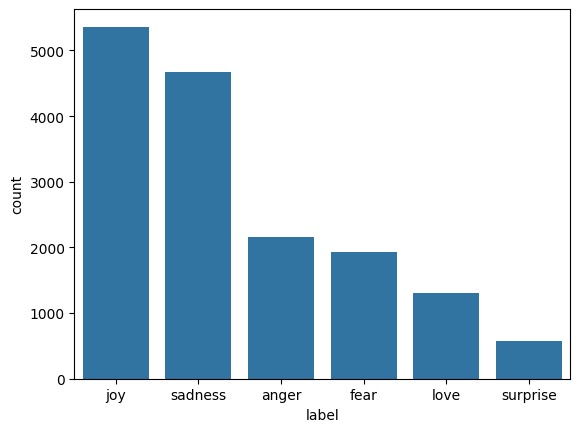

In [8]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words=10000



tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


In [10]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [13]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.1,
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.1606 - loss: 2.0482 - val_accuracy: 0.1312 - val_loss: 1.7811
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.1504 - loss: 1.8901 - val_accuracy: 0.2906 - val_loss: 1.7674
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.1419 - loss: 1.8286 - val_accuracy: 0.0319 - val_loss: 1.8146
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.1242 - loss: 1.8115 - val_accuracy: 0.1363 - val_loss: 1.7872
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.1240 - loss: 1.8059 - val_accuracy: 0.3131 - val_loss: 1.7531
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.1285 - loss: 1.8068 - val_accuracy: 0.1225 - val_loss: 1.7552
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - accuracy: 0.1424 - loss: 1.8033 - val_accuracy: 0.3044 - val_loss: 1.7469
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.1353 - loss: 1.8041 - 

In [14]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.1,
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 65s 134ms/step - accuracy: 0.1507 - loss: 1.7992 - val_accuracy: 0.0306 - val_loss: 1.8169
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 58s 129ms/step - accuracy: 0.1445 - loss: 1.7978 - val_accuracy: 0.3187 - val_loss: 1.7826
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 63s 140ms/step - accuracy: 0.1471 - loss: 1.7965 - val_accuracy: 0.3056 - val_loss: 1.7871
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.0330 - loss: 1.8190
LSTM Loss: 1.8189505338668823
LSTM Accuracy: 0.032999999821186066


In [15]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.1,
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 54s 113ms/step - accuracy: 0.1366 - loss: 1.7998 - val_accuracy: 0.0312 - val_loss: 1.7838
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 49s 110ms/step - accuracy: 0.1536 - loss: 1.7985 - val_accuracy: 0.3075 - val_loss: 1.7355
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 51s 113ms/step - accuracy: 0.1603 - loss: 1.7981 - val_accuracy: 0.1244 - val_loss: 1.7851
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 51s 113ms/step - accuracy: 0.1421 - loss: 1.7981 - val_accuracy: 0.0794 - val_loss: 1.8003
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 83s 115ms/step - accuracy: 0.1338 - loss: 1.7969 - val_accuracy: 0.3013 - val_loss: 1.7747
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.2905 - loss: 1.7393
GRU Loss: 1.7392808198928833
GRU Accuracy: 0.2904999852180481


In [17]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
2,GRU,1.739281,0.2905
0,RNN,1.746076,0.2855
1,LSTM,1.818951,0.0330


In [18]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_split=0.1,
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 149s 320ms/step - accuracy: 0.4740 - loss: 1.1798 - val_accuracy: 0.8813 - val_loss: 0.3640
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 200s 316ms/step - accuracy: 0.9109 - loss: 0.2687 - val_accuracy: 0.9237 - val_loss: 0.2178
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 142s 316ms/step - accuracy: 0.9429 - loss: 0.1569 - val_accuracy: 0.9262 - val_loss: 0.2086
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 143s 317ms/step - accuracy: 0.9610 - loss: 0.1144 - val_accuracy: 0.9187 - val_loss: 0.2750
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 142s 315ms/step - accuracy: 0.9689 - loss: 0.0899 - val_accuracy: 0.9187 - val_loss: 0.2792
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 140s 312ms/step - accuracy: 0.9753 - loss: 0.0698 - val_accuracy: 0.9219 - val_loss: 0.2541
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9160 - loss: 0.2489
BiGRU Loss: 0.24888530373573303
BiGRU Accuracy: 0.9160000085830688


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step


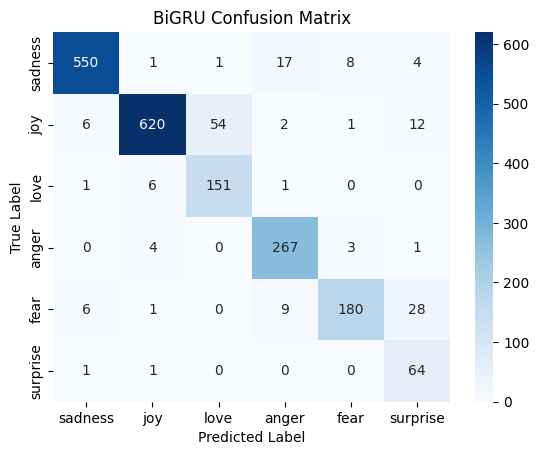

In [20]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

cm = confusion_matrix(test_labels, BiGRU_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('BiGRU Confusion Matrix')
plt.show()

In [21]:
sample_texts = [
    "I am so happy that I finally got the job!",
    "I feel completely alone and miserable.",
    "This situation is making me extremely angry.",
    "I am terrified of what might happen next.",
    "I love my family more than anything.",
    "Wow, I never expected this to happen!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Text: I am so happy that I finally got the job!
Predicted Emotion: joy
Text: I feel completely alone and miserable.
Predicted Emotion: sadness
Text: This situation is making me extremely angry.
Predicted Emotion: anger
Text: I am terrified of what might happen next.
Predicted Emotion: fear
Text: I love my family more than anything.
Predicted Emotion: anger
Text: Wow, I never expected this to happen!
Predicted Emotion: anger


In [22]:
import os
import pickle
model_dir='Artifacts'

os.makedirs(model_dir,exist_ok=True)

BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)